In [ ]:
from pathlib import Path
import numpy as np
import xarray as xr
import xesmf as xe

from load_cmip_esgf import CMIPESGFLoader, data_dict_nybtes, align_dicts
import xclimate as xclim

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# %load_ext autoreload
# %autoreload 2

In [3]:
def add_gridlines(ax, lat_bnds):
    x_gls = np.arange(-180, 181, 30)
    y_gls = np.arange(-90, 91, 30)
    y_gls = y_gls[(y_gls >= lat_bnds.start) & (y_gls <= lat_bnds.stop)]
    ax.gridlines(
        draw_labels=False,
        xlocs=x_gls,
        ylocs=y_gls,
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--",
    )

In [4]:
client_cluster = xclim.create_dask_cluster(
    account="UWAS0155",
    nworkers=4,
    nmem="5GB",
    walltime="04:00:00",
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  5GB
walltime: 04:00:00
{}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.162:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


In [5]:
CATALOG_ROOT = Path("/glade/campaign/univ/uwas0155/catalogs")

loader_cmip = CMIPESGFLoader(CATALOG_ROOT / "cmip6.csv")

loader_cesm = CMIPESGFLoader(CATALOG_ROOT / "cmip6_cesm_mon.csv")
loader_cesm_grid = CMIPESGFLoader(CATALOG_ROOT / "cmip6_cesm_fx.csv")

loader_regrid = CMIPESGFLoader(CATALOG_ROOT / "cmip6_regridded.csv")

VARIABLE_ID = ["evspsbl", "pr", "rsds", "rlds"]
GRID_VARIABLE_ID = ["sftlf", "areacella"]
EXPERIMENT_ID = "historical"
MEMBER_ID = "top"
OMIT_SOURCE_IDS = ["EC-Earth3", "EC-Earth3-AerChem", "EC-Earth3-ESM-1", "EC-Earth3-HR", "EC-Earth3-Veg", "EC-Earth3-Veg-LR"]
TIME_SLICE = slice("1950-01", None)
DO_PARALLEL = True
DO_COMPUTE = True

In [2]:
d1 = {
    1: "a"
}
d2 = {2: "b"}
d3 = {3: "c"}

d1 | d2 | d3

{1: 'a', 2: 'b', 3: 'c'}

In [6]:
dd_cmip = loader_cmip.load_data(
    variables=VARIABLE_ID,
    experiment_id=EXPERIMENT_ID,
    source_id=None,
    omit_source_id=OMIT_SOURCE_IDS,
    member_id=MEMBER_ID,
    time_slice=TIME_SLICE,
    parallel=DO_PARALLEL,
    compute=DO_COMPUTE,
)

dd_cesm = loader_cesm.load_data(
    variables=VARIABLE_ID,
    experiment_id=EXPERIMENT_ID,
    source_id=None,
    omit_source_id=OMIT_SOURCE_IDS,
    source_candidates=["CESM2", "CESM2-WACCM", "CESM2-FV2", "CESM2-WACCM-FV2"],
    member_id=MEMBER_ID,
    time_slice=TIME_SLICE,
    parallel=DO_PARALLEL,
    compute=DO_COMPUTE,
)

number of models with areacella and sftlf: 44
only selecting top member_id
=== ACCESS-CM2 ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== ACCESS-ESM1-5 ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== AWI-CM-1-1-MR ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== AWI-ESM-1-1-LR ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== AWI-ESM-1-REcoM ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== CMCC-CM2-SR5 ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds      

In [7]:
# Merge dicts
dd_cmip = dd_cmip | dd_cesm

In [8]:
dd_cmip_grid = loader_cmip.load_data(
    variables=GRID_VARIABLE_ID,
    experiment_id=EXPERIMENT_ID,
    source_id=None,
    omit_source_id=OMIT_SOURCE_IDS,
    member_id="top",
    time_slice=TIME_SLICE,
    parallel=DO_PARALLEL,
    compute=DO_COMPUTE,
)

dd_cesm_grid = loader_cesm_grid.load_data(
    variables=GRID_VARIABLE_ID,
    experiment_id=EXPERIMENT_ID,
    source_id=None,
    omit_source_id=OMIT_SOURCE_IDS,
    source_candidates=["CESM2", "CESM2-WACCM", "CESM2-FV2", "CESM2-WACCM-FV2"],
    member_id="top",
    time_slice=TIME_SLICE,
    parallel=DO_PARALLEL,
    compute=DO_COMPUTE,
)

number of models with areacella and sftlf: 44
only selecting top member_id
=== ACCESS-CM2 ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== ACCESS-ESM1-5 ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== AWI-CM-1-1-MR ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== AWI-ESM-1-1-LR ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== AWI-ESM-1-REcoM ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== CMCC-CM2-SR5 ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== CMCC-ESM2 ===
  sftlf        n=1     ✅r1i1p1f1 
  areacella    n=1     ✅r1i1p1f1 
=== CNRM-CM6-1 ===
  sftlf        n=1     ✅r2i1p1f2 
  areacella    n=1     ✅r2i1p1f2 
=== CNRM-CM6-1-HR ===
  sftlf        n=1     ✅r1i1p1f2 
  areacella    n=1     ✅r1i1p1f2 
=== CNRM-ESM2-1 ===
  sftlf        n=1     ✅r2i1p1f2 
  areacella    n=1     ✅r2i1p1f2 
=== CanESM5 ===
  sftlf        n=1 

In [9]:
# Merge dicts
dd_cmip_grid = dd_cmip_grid | dd_cesm_grid

In [10]:
for i, (sid, vardict) in enumerate(dd_cmip_grid.items()):
    if len(vardict.keys()) > 0:
        dd_cmip_grid[sid]["lf"] = dd_cmip_grid[sid]["sftlf"].reindex_like(dd_cmip_grid[sid]["areacella"], method="nearest", tolerance=1e-3)
        dd_cmip_grid[sid]["la"] = dd_cmip_grid[sid]["areacella"] * dd_cmip_grid[sid]["lf"]

In [16]:
dd_cmip_aligned, dd_cmip_grid_aligned = align_dicts(dd_cmip, dd_cmip_grid)

print("ORIGINAL")
print(f"number of CMIP models: {len(dd_cmip.keys())}")
print(f"number of CMIP models: {len(dd_cmip_grid.keys())}")

print("\nALIGNED")
print(f"number of CMIP models: {len(dd_cmip_aligned.keys())}")
print(f"number of CMIP models: {len(dd_cmip_grid_aligned.keys())}")

print("\nDROPPED")
print(f"{set(dd_cmip.keys()) - set(dd_cmip_aligned.keys())}")
print(f"{set(dd_cmip_grid.keys()) - set(dd_cmip_grid_aligned.keys())}")

ORIGINAL
number of CMIP models: 42
number of CMIP models: 42

ALIGNED
number of CMIP models: 41
number of CMIP models: 41

DROPPED
{'MIROC-ES2H'}
{'MIROC-ES2H'}


In [17]:
# data_dict_nybtes(dd_cmip_aligned);

In [18]:
# data_dict_nybtes(dd_cmip_grid_aligned);

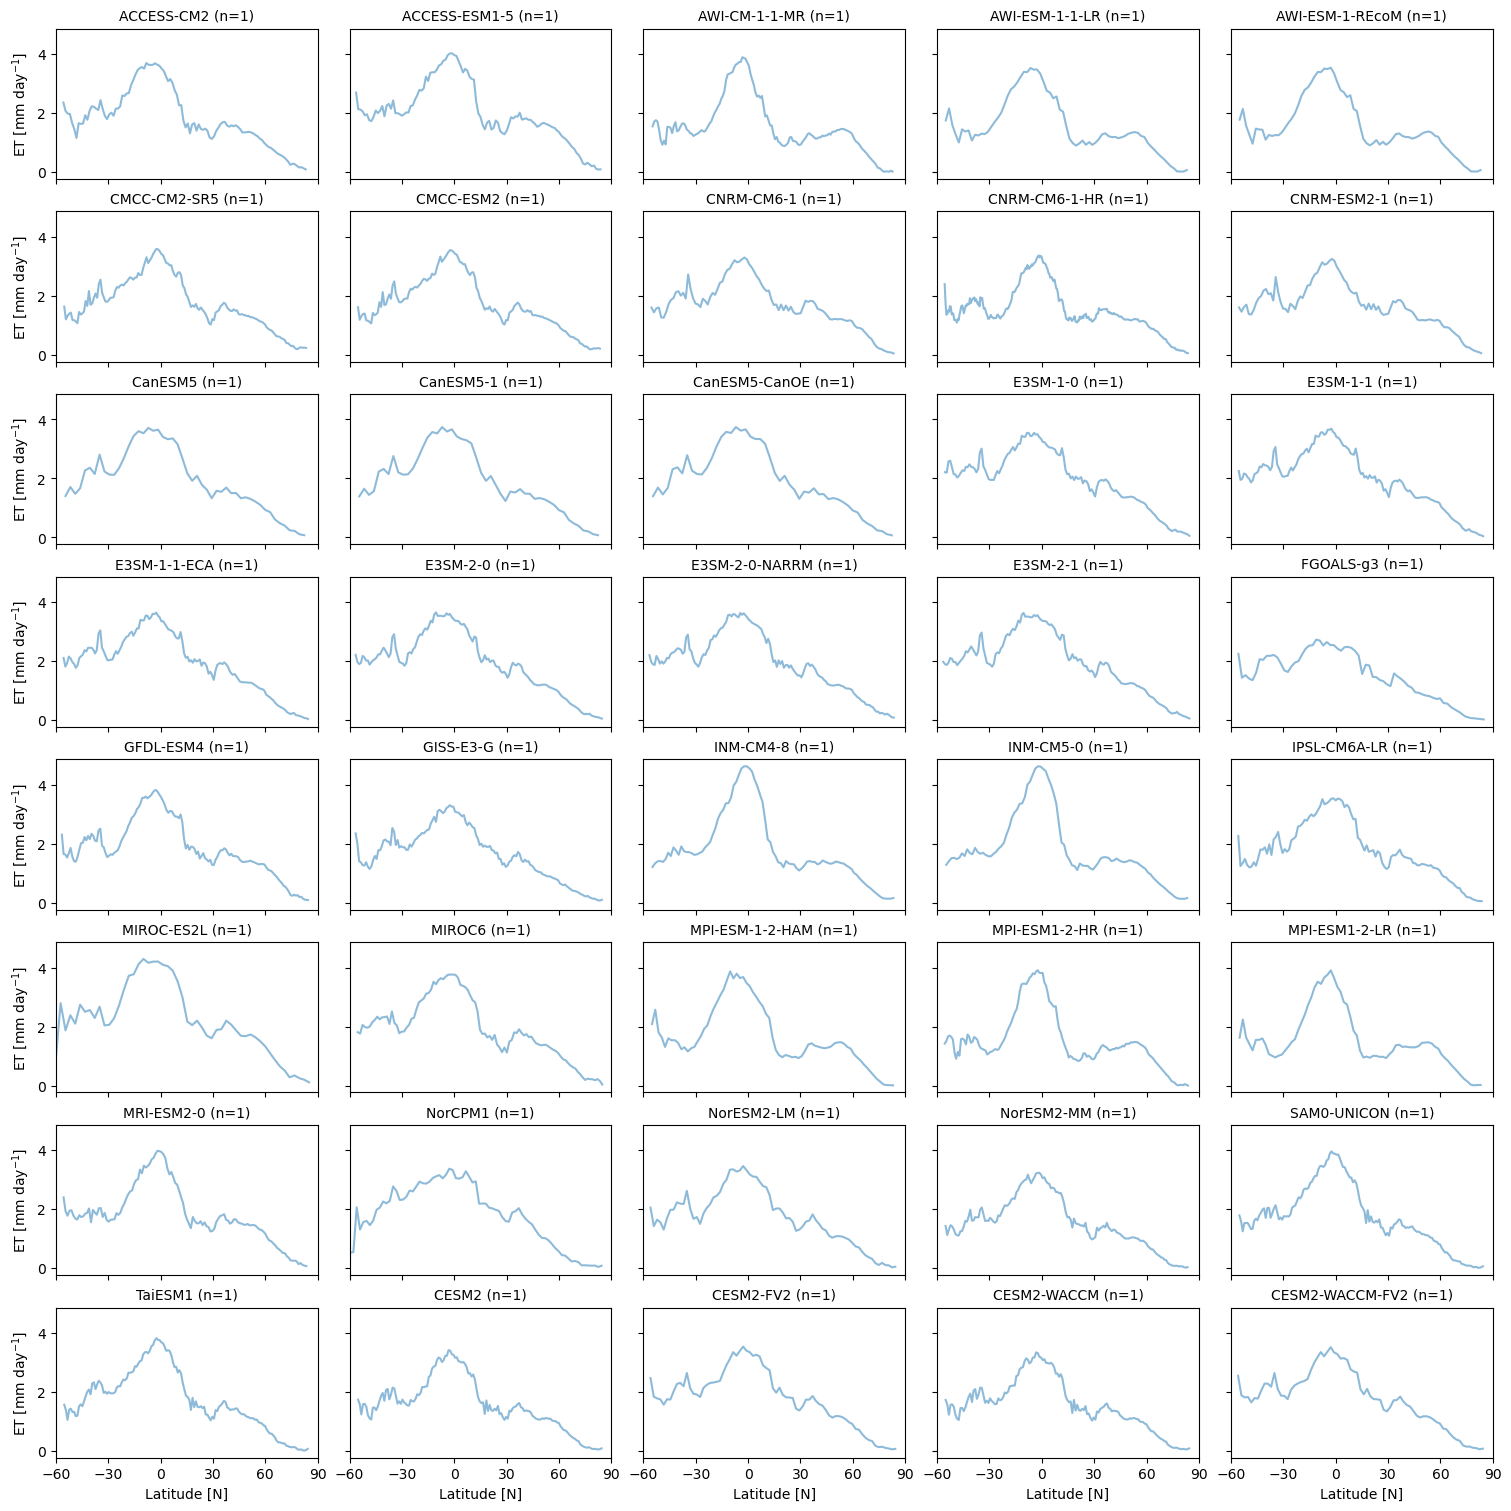

In [19]:
v = "evspsbl"
cf = 86400
cs = 0
time_bnds = slice("1995-01", "2014-12")
lat_bnds = slice(-60, 90)
lf_thresh = 0.50
verbose = False

nrows = 8
ncols = 5

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15), layout="constrained", sharex=True, sharey=True)
axs = axes.ravel()

nremove = 0
for i, (sid, vardict) in enumerate(dd_cmip_aligned.items()):
    # print(sid)
    
    if (v in vardict.keys()) and ("lon" in vardict[v].dims) and ("lat" in vardict[v].dims):

        lf = dd_cmip_grid[sid]["lf"].reindex_like(vardict[v], method="nearest", tolerance=1e-3)
        da = vardict[v].where(lf > lf_thresh).sel(time=time_bnds, lat=lat_bnds) * cf + cs

        if verbose:
            print(f"{sid:20}: {dd_cmip_grid[sid]['lf'].shape} {vardict[v].shape}")
    
        if ("member" in da.dims) and (len(da.member) > 1):
            for m in da.member:
                da.sel(member=m).mean(dim=["time", "lon"]).plot(ax=axs[i-nremove], color="tab:blue", alpha=0.25, _labels=False)
            axs[i-nremove].set_title(f"{sid} (n={len(da.member):d})", fontsize=10)
        else:
            da.mean(dim=["time", "lon"]).plot(ax=axs[i-nremove], color="tab:blue", alpha=0.5, _labels=False)
            axs[i-nremove].set_title(f"{sid} (n=1)", fontsize=10)

    else:
        nremove += 1
        if verbose:
            print(f"❌{sid:20}")

for i in range(ncols):
    axes[-1, i].set_xlabel("Latitude [N]")

for i in range(nrows):
    axes[i, 0].set_ylabel("ET [mm day$^{-1}$]")

for ax in axs:
    ax.set_xlim(lat_bnds.start, lat_bnds.stop)
    ax.set_xticks([-60, -30, 0, 30, 60, 90])

# extra_plots = len(axs) - len(dd_cmip_aligned.keys()) + nremove
# for ax in axs[-extra_plots:]:
#     ax.remove()

Text(0, 0.5, 'ET [mm day$^{-1}$]')

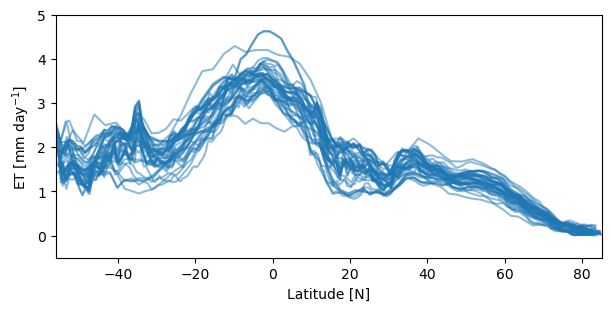

: 

In [ ]:
v = "evspsbl"
cf = 86400
cs = 0
time_bnds = slice("1995-01", "2014-12")
lat_bnds = slice(-56, 85)
lf_thresh = 0.50

fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")

for i, (sid, vardict) in enumerate(dd_cmip_aligned.items()):    
    if (v in vardict.keys()) and ("lon" in vardict[v].dims) and ("lat" in vardict[v].dims):

        lf = dd_cmip_grid[sid]["lf"].reindex_like(vardict[v], method="nearest", tolerance=1e-3)
        da = vardict[v].where(lf > lf_thresh).sel(time=time_bnds, lat=lat_bnds) * cf + cs
    
        if ("member" in da.dims) and (len(da.member) > 1):
            for m in da.member:
                da.sel(member=m).mean(dim=["time", "lon"]).plot(ax=ax, color="tab:blue", alpha=0.25, _labels=False)
        else:
            da.mean(dim=["time", "lon"]).plot(ax=ax, color="tab:blue", alpha=0.5, _labels=False)

ax.set_xlim(-56, 85)
ax.set_ylim(-0.5, 5)
ax.set_xlabel("Latitude [N]")
ax.set_ylabel("ET [mm day$^{-1}$]")

In [ ]:
v = "evspsbl"
cf = 86400
cs = 0
time_bnds = slice("1995-01", "2014-12")
lat_bnds = slice(-58, 90)
lf_thresh = 0.50
verbose = False

subplot_kwargs = dict(
    vmin=0,
    vmax=5,
    # cbar_kwargs={"extend": "max"},
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    add_labels=False,
)

nrows = 8
ncols = 5

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(16, 15),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True, sharey=True,
    layout="constrained"
)
axs = axes.ravel()

nremove = 0
for i, (sid, vardict) in enumerate(dd_cmip_aligned.items()):
    if (v in vardict.keys()) and ("lon" in vardict[v].dims) and ("lat" in vardict[v].dims):

        lf = dd_cmip_grid[sid]["lf"].reindex_like(vardict[v], method="nearest", tolerance=1e-3)
        da = vardict[v].where(lf > lf_thresh).sel(time=time_bnds, lat=lat_bnds) * cf + cs

        if verbose:
            print(f"{sid:20}: {dd_cmip_grid[sid]['lf'].shape} {vardict[v].shape}")
    
        if ("member" in da.dims) and (len(da.member) > 1):
            for m in da.member:
                im = da.sel(member=m).mean(dim=["time"]).plot(ax=axs[i-nremove], **subplot_kwargs)
            axs[i-nremove].set_title(f"{sid} (n={len(da.member):d})", fontsize=10)
        else:
            im = da.mean(dim=["time"]).plot(ax=axs[i-nremove], **subplot_kwargs)
            axs[i-nremove].set_title(f"{sid} (n=1)", fontsize=10)

    else:
        nremove += 1
        if verbose:
            print(f"❌{sid:20}")

cb = fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.025, extend="max")
cb.set_label("ET [mm day$^{-1}$]")

for ax in axs:
    add_gridlines(ax, lat_bnds)

# extra_plots = len(axs) - len(dd_cmip_aligned.keys()) + nremove
# for ax in axs[-extra_plots:]:
#     ax.remove()

In [ ]:
# xclim.close_dask_cluster(client_cluster, remove_std_files=True)